In [2]:
#type: ignore
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from typing import List, Literal
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier 
# from sentence_transformers import SentenceTransformer 
from sklearn.preprocessing import StandardScaler

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('data.csv')
df.head()

,review,target
0,sản_phẩm đẹp hình,1
1,giao hàng rất nhanh cần gấp nấu mở thất_vọng v...,0
2,chảo vênh lòng cao giữa trũng xung_quanh rán k...,0
3,hàng tốt,1
4,bình tốt giá_cả hợp_lý màu tím thiên màu tím t...,1


In [4]:
df['target'].value_counts().to_frame()

,count
target,
1,49719
0,10960


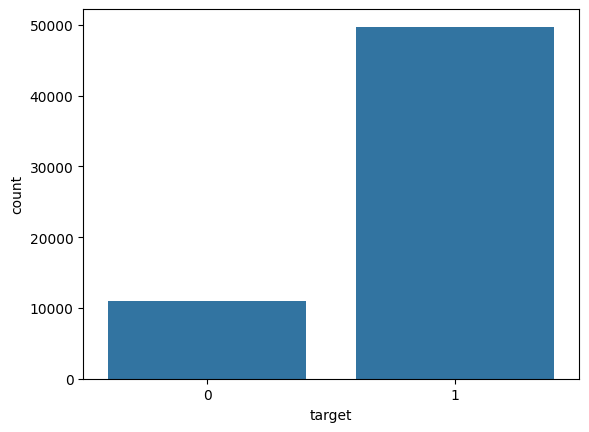

In [5]:
sns.countplot(data=df, x='target');

In [6]:
x_full, y_full = df['review'], df['target']
SEED = 42

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x_full, y_full, test_size=0.2, stratify=y_full, random_state=SEED)


In [9]:
class EmbeddingVectorizer: 
    def __init__(self, model_name: str = 'intfloat/multilingual-e5-base', normalize: bool = True): 
        self.model = SentenceTransformer(model_name)
        self.normalize = normalize
    def _format_inputs(self, texts:List[str], mode: Literal['query', 'passage']):
        if mode not in {'query', 'passage'}: 
            raise ValueError ("Mode must be either query or passage") 
        return [f"{mode}: {text.strip()}" for text in texts] 
    def transform(self, texts: List[str], mode: Literal['query', 'passage'] = 'query'): 
        if mode == 'raw': 
            inputs = texts
        else: 
            inputs = self._format_inputs(texts, mode) 
        embeddings = self.model.encode(inputs, normalize_embeddings=self.normalize) 
        return embeddings.tolist() 
    def transform_numpy(self, texts: List[str], mode: Literal['query', 'passage'] = 'query'): 
        return np.array(self.transform(texts, mode=mode)) 

In [8]:
tfidf_vectorizer = TfidfVectorizer()
x_train_tfidf = tfidf_vectorizer.fit_transform(x_train)
x_test_tfidf = tfidf_vectorizer.transform(x_test)

In [10]:
bow_vectorizer = CountVectorizer()
x_train_bow = bow_vectorizer.fit_transform(x_train)
x_test_bow = bow_vectorizer.transform(x_test)

tfidf_vectorizer = TfidfVectorizer()
x_train_tfidf = tfidf_vectorizer.fit_transform(x_train)
x_test_tfidf = tfidf_vectorizer.transform(x_test)

embedding_vectorizer = EmbeddingVectorizer()
x_train_embeddings = embedding_vectorizer.transform(x_train) 
x_test_embeddings = embedding_vectorizer.transform(x_test) 

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

KeyboardInterrupt: 

In [ ]:
def mean_f1_score(x_train, y_train, model, n_splits = 5):
    if isinstance(x_train, list): x_train = np.array(x_train) 
    if isinstance(model, LGBMClassifier): 
        x_train = x_train.astype('float32')
    if isinstance(model, GaussianNB): 
        x_train = x_train.toarray() if hasattr(x_train, 'toarray') else x_train  
    skf = StratifiedKFold(n_splits=n_splits, random_state=SEED, shuffle=True)  
    score = cross_val_score(model, x_train, y_train, cv=skf, scoring='f1_macro')  
    return score.mean() 

In [ ]:
bow_f1 = mean_f1_score(x_train_bow, y_train, KNeighborsClassifier()) 
tfidf_f1 = mean_f1_score(x_train_tfidf, y_train, KNeighborsClassifier()) 
embedding_f1 = mean_f1_score(x_train_embeddings, y_train, KNeighborsClassifier()) 
print(f"F1_Score for {KNeighborsClassifier()}:")
print(f"Bow of Word: {bow_f1:.4f}") 
print(f"TF-IDF: {tfidf_f1:.4f}") 
print(f"SentenceTransformer: {embedding_f1:.4f}") 
print("--"*50)

F1_Score for KNeighborsClassifier():
Bow of Word: 0.6904
TF-IDF: 0.5557
SentenceTransformer: 0.7527
----------------------------------------------------------------------------------------------------


In [ ]:
bow_f1 = mean_f1_score(x_train_bow, y_train, LogisticRegression()) 
tfidf_f1 = mean_f1_score(x_train_tfidf, y_train, LogisticRegression()) 
embedding_f1 = mean_f1_score(x_train_embeddings, y_train, LogisticRegression()) 
print(f"F1_Score for {LogisticRegression()}:")
print(f"Bow of Word: {bow_f1:.4f}") 
print(f"TF-IDF: {tfidf_f1:.4f}") 
print(f"SentenceTransformer: {embedding_f1:.4f}") 
print("--"*50)

F1_Score for LogisticRegression():
Bow of Word: 0.8068
TF-IDF: 0.8003
SentenceTransformer: 0.7941
----------------------------------------------------------------------------------------------------


In [ ]:
bow_f1 = mean_f1_score(x_train_bow, y_train, LinearSVC(random_state=SEED)) 
tfidf_f1 = mean_f1_score(x_train_tfidf, y_train, LinearSVC(random_state=SEED)) 
embedding_f1 = mean_f1_score(x_train_embeddings, y_train, LinearSVC(random_state=SEED)) 
print(f"F1_Score for {LinearSVC()}:")
print(f"Bow of Word: {bow_f1:.4f}") 
print(f"TF-IDF: {tfidf_f1:.4f}") 
print(f"SentenceTransformer: {embedding_f1:.4f}") 
print("--"*50) 

F1_Score for LinearSVC():
Bow of Word: 0.7922
TF-IDF: 0.8004
SentenceTransformer: 0.8083
----------------------------------------------------------------------------------------------------


In [ ]:
bow_f1 = mean_f1_score(x_train_bow, y_train, MultinomialNB()) 
tfidf_f1 = mean_f1_score(x_train_tfidf, y_train, MultinomialNB()) 
embedding_f1 = mean_f1_score(x_train_embeddings, y_train, GaussianNB()) 
print(f"F1_Score for Naive Bayes:")
print(f"Bow of Word: {bow_f1:.4f}") 
print(f"TF-IDF: {tfidf_f1:.4f}") 
print(f"SentenceTransformer: {embedding_f1:.4f}") 
print("--"*50) 

F1_Score for Naive Bayes:
Bow of Word: 0.7949
TF-IDF: 0.6227
SentenceTransformer: 0.7583
----------------------------------------------------------------------------------------------------


In [ ]:
bow_f1 = mean_f1_score(x_train_bow, y_train, XGBClassifier()) 
tfidf_f1 = mean_f1_score(x_train_tfidf, y_train, XGBClassifier()) 
embedding_f1 = mean_f1_score(x_train_embeddings, y_train, XGBClassifier()) 
print(f"F1_Score for {XGBClassifier()}:")
print(f"Bow of Word: {bow_f1:.4f}") 
print(f"TF-IDF: {tfidf_f1:.4f}") 
print(f"SentenceTransformer: {embedding_f1:.4f}") 
print("--"*50) 

F1_Score for XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...):
Bow of Word: 0.7959
TF-IDF: 0.7990
SentenceTransformer: 0.7898
----------------------------------------------------------------------------------------------------


In [ ]:
bow_f1 = mean_f1_score(x_train_bow, y_train, LGBMClassifier()) 
tfidf_f1 = mean_f1_score(x_train_tfidf, y_train, LGBMClassifier()) 
embedding_f1 = mean_f1_score(x_train_embeddings, y_train, LGBMClassifier()) 
print(f"F1_Score for {LGBMClassifier()}:")
print(f"Bow of Word: {bow_f1:.4f}") 
print(f"TF-IDF: {tfidf_f1:.4f}") 
print(f"SentenceTransformer: {embedding_f1:.4f}") 
print("--"*50)

[LightGBM] [Info] Number of positive: 31820, number of negative: 7014
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.372851 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5678
[LightGBM] [Info] Number of data points in the train set: 38834, number of used features: 1739
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.819385 -> initscore=1.512187
[LightGBM] [Info] Start training from score 1.512187


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 31820, number of negative: 7014
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.374095 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5803
[LightGBM] [Info] Number of data points in the train set: 38834, number of used features: 1767
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.819385 -> initscore=1.512187
[LightGBM] [Info] Start training from score 1.512187


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 31820, number of negative: 7014
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.392105 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5784
[LightGBM] [Info] Number of data points in the train set: 38834, number of used features: 1767
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.819385 -> initscore=1.512187
[LightGBM] [Info] Start training from score 1.512187


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 31820, number of negative: 7015
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.449139 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 195840
[LightGBM] [Info] Number of data points in the train set: 38835, number of used features: 768
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.819364 -> initscore=1.512044
[LightGBM] [Info] Start training from score 1.512044


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 31820, number of negative: 7015
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.476355 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 195840
[LightGBM] [Info] Number of data points in the train set: 38835, number of used features: 768
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.819364 -> initscore=1.512044
[LightGBM] [Info] Start training from score 1.512044
F1_Score for LGBMClassifier():
Bow of Word: 0.8059
TF-IDF: 0.8083
SentenceTransformer: 0.7892
----------------------------------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
bow_f1 = mean_f1_score(x_train_bow, y_train, DecisionTreeClassifier(max_depth=10, min_samples_split=10, random_state=SEED))  
tfidf_f1 = mean_f1_score(x_train_tfidf, y_train, DecisionTreeClassifier(max_depth=10, min_samples_split=10, random_state=SEED)) 
embedding_f1 = mean_f1_score(x_train_embeddings, y_train, DecisionTreeClassifier(max_depth=10, min_samples_split=10, random_state=SEED)) 
print(f"F1_Score for {DecisionTreeClassifier()}:")
print(f"Bow of Word: {bow_f1:.4f}") 
print(f"TF-IDF: {tfidf_f1:.4f}") 
print(f"SentenceTransformer: {embedding_f1:.4f}") 
print("--"*50) 

F1_Score for DecisionTreeClassifier():
Bow of Word: 0.7394
TF-IDF: 0.7350
SentenceTransformer: 0.6832
----------------------------------------------------------------------------------------------------


In [ ]:
bow_f1 = mean_f1_score(x_train_bow, y_train, RandomForestClassifier(max_depth=10, min_samples_split=10, random_state=SEED))  
tfidf_f1 = mean_f1_score(x_train_tfidf, y_train, RandomForestClassifier(max_depth=10, min_samples_split=10, random_state=SEED)) 
embedding_f1 = mean_f1_score(x_train_embeddings, y_train, RandomForestClassifier(max_depth=10, min_samples_split=10, random_state=SEED)) 
print(f"F1_Score for {RandomForestClassifier()}:")
print(f"Bow of Word: {bow_f1:.4f}") 
print(f"TF-IDF: {tfidf_f1:.4f}") 
print(f"SentenceTransformer: {embedding_f1:.4f}") 
print("--"*50)

F1_Score for RandomForestClassifier():
Bow of Word: 0.4514
TF-IDF: 0.4504
SentenceTransformer: 0.6345
----------------------------------------------------------------------------------------------------


In [ ]:
bow_f1 = mean_f1_score(x_train_bow, y_train, AdaBoostClassifier(n_estimators=20, random_state=SEED))  
tfidf_f1 = mean_f1_score(x_train_tfidf, y_train, AdaBoostClassifier(n_estimators=20, random_state=SEED)) 
embedding_f1 = mean_f1_score(x_train_embeddings, y_train, AdaBoostClassifier(n_estimators=20, random_state=SEED)) 
print(f"F1_Score for {AdaBoostClassifier()}:")
print(f"Bow of Word: {bow_f1:.4f}") 
print(f"TF-IDF: {tfidf_f1:.4f}") 
print(f"SentenceTransformer: {embedding_f1:.4f}") 
print("--"*50)

F1_Score for AdaBoostClassifier():
Bow of Word: 0.7044
TF-IDF: 0.7106
SentenceTransformer: 0.7175
----------------------------------------------------------------------------------------------------


In [12]:
def train_and_test_linearSVC(x_train, y_train, x_test, y_test):
    lsvc = LinearSVC() 
    lsvc.fit(x_train, y_train)

    y_pred = lsvc.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred)

    report = classification_report(y_test, y_pred, output_dict=True)

    return y_pred, accuracy, report

In [14]:
lsvc_bow_labels, lsvc_bow_accuracy, lsvc_bow_report = train_and_test_linearSVC(x_train_bow, y_train, x_test_bow, y_test)
lsvc_tfidf_labels, lsvc_tfidf_accuracy, lsvc_tfidf_report = train_and_test_linearSVC(x_train_tfidf, y_train, x_test_tfidf, y_test)
lsvc_embedding_labels, lsvc_embedding_accuracy, lsvc_embedding_report = train_and_test_linearSVC(x_train_embeddings, y_train, x_test_embeddings, y_test)

In [13]:
def plot_confusion_matrix(y_true, y_pred, figure_name='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    cm_percent = cm.astype('float')/cm.sum(axis=1)[:, np.newaxis] * 100 
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent)
    disp.plot(cmap=plt.cm.Blues, values_format='.2f')
    plt.title(figure_name)
    plt.show()

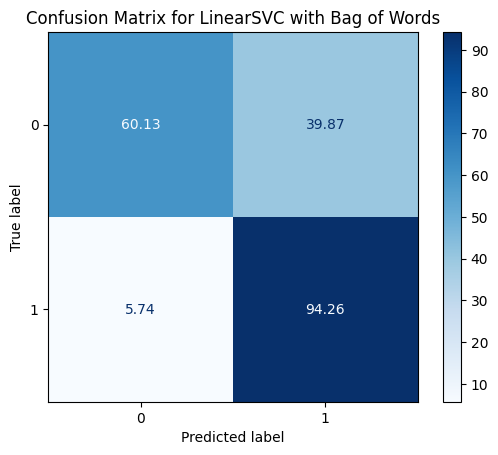

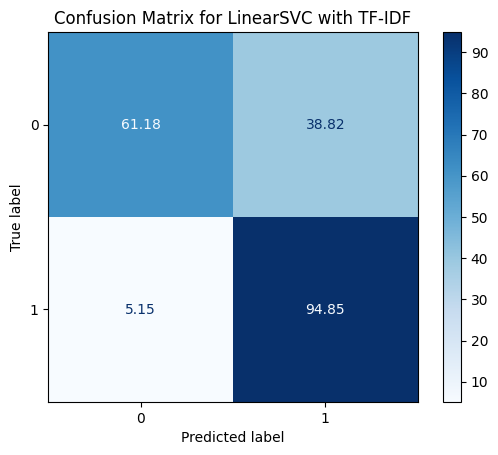

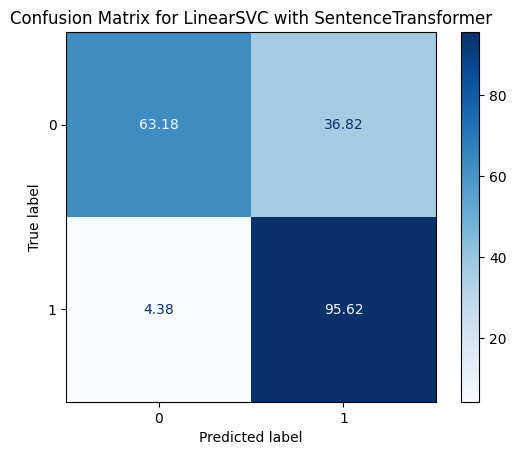

In [15]:
plot_confusion_matrix(y_test, lsvc_bow_labels, figure_name='Confusion Matrix for LinearSVC with Bag of Words')
plot_confusion_matrix(y_test, lsvc_tfidf_labels, figure_name='Confusion Matrix for LinearSVC with TF-IDF')
plot_confusion_matrix(y_test, lsvc_embedding_labels, figure_name='Confusion Matrix for LinearSVC with SentenceTransformer')

### Tune

In [10]:
def find_best_params(x_train, y_train, param_grid=None, scoring='f1_macro', cv_splits = 5, class_weight = 'balanced', max_iter = 10000, random_state=42): 
    svc = LinearSVC(max_iter=max_iter, random_state=random_state, class_weight=class_weight)
    if param_grid is None: 
        param_grid = {
            'loss': ['hinge', 'squared_hinge'],
            'C': [0.001, 0.01, 0.1, 10]
        }
    skf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)
    grid = GridSearchCV(estimator=svc, param_grid=param_grid, scoring=scoring, cv=skf, n_jobs = -1)  
    grid.fit(x_train, y_train) 
    return grid.best_estimator_, grid.best_params_, grid.best_score_ 

In [13]:
bow_model, bow_params, bow_score = find_best_params(x_train_bow, y_train) 

In [14]:
print(bow_model, bow_params, bow_score)

LinearSVC(C=0.1, class_weight='balanced', max_iter=10000, random_state=42) {'C': 0.1, 'loss': 'squared_hinge'} 0.8020413016799545


In [15]:
tfidf_model, tfidf_params, tfidf_score = find_best_params(x_train_tfidf, y_train) 

In [17]:
print(tfidf_model, tfidf_params, tfidf_score)

LinearSVC(C=0.1, class_weight='balanced', max_iter=10000, random_state=42) {'C': 0.1, 'loss': 'squared_hinge'} 0.8008569329819991


In [9]:
svc = LinearSVC(loss='squared_hinge', C=0.1, class_weight='balanced', max_iter=10000, random_state=SEED)

svc.fit(x_train_tfidf, y_train) 

y_pred = svc.predict(x_test_tfidf) 

report = classification_report(y_test, y_pred)
print(report) 


              precision    recall  f1-score   support

           0       0.56      0.85      0.68      2192
           1       0.96      0.85      0.91      9944

    accuracy                           0.85     12136
   macro avg       0.76      0.85      0.79     12136
weighted avg       0.89      0.85      0.86     12136



In [17]:
text = ["sản phẩm tốt", "sản phẩm không tốt", "lỗi vặt", "xấu", "chả ra gì", "nhu db", "khong tot nhu loi don thoi"] 

test = tfidf_vectorizer.transform(text) 

label = svc.predict(test) 
print(label)

[1 0 0 0 0 0 0]


In [10]:
import joblib 

joblib.dump(tfidf_vectorizer, "./tfidf_vectorizer.pkl")
joblib.dump(svc, "./linearsvc_model.pkl")

['./linearsvc_model.pkl']